<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/Assignments/final_6070_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup and Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/MSSP607/Assignments/pdp_state_releases.csv'

try:
    df = pd.read_csv(file_path)
    print(f'Successfully loaded data from {file_path}. First 5 rows:')
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/MyDrive/MSSP607/Assignments/pdp_state_releases.csv. First 5 rows:


,custody_agency,date_of_release,sex,age,race_ethnicity,zip
0,PDP,2015-06-19 00:00:00,Male,34,Black,NaN
1,State,2015-09-08 00:00:00,Male,66,Black,19133.0
2,PDP,2015-10-02 00:00:00,Male,61,Black,19132.0
3,PDP,2015-05-05 00:00:00,Female,41,Black,NaN
4,PDP,2015-01-08 00:00:00,Male,23,White,19134.0


In [ ]:
# inspect values
print("\nConcise summary of the DataFrame:\n")
df.info()

print("\nNumber of unique values in each column:\n")
print(df.nunique())

print("\nSum of missing values for each column:\n")
print(df.isnull().sum())


Concise summary of the DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24089 entries, 0 to 24088
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   custody_agency   24089 non-null  object 
 1   date_of_release  24089 non-null  object 
 2   sex              24076 non-null  object 
 3   age              24089 non-null  int64  
 4   race_ethnicity   24089 non-null  object 
 5   zip              20524 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ MB

Number of unique values in each column:

custody_agency       2
date_of_release    365
sex                  2
age                 69
race_ethnicity       5
zip                146
dtype: int64

Sum of missing values for each column:

custody_agency        0
date_of_release       0
sex                  13
age                   0
race_ethnicity        0
zip                3565
dtype: int64


# 2. Variable Selection and Data Cleaning


In [ ]:
# 2.1 Convert date_of_release to datetime
print("1. Converting 'date_of_release' to datetime objects...")
df['date_of_release'] = pd.to_datetime(df['date_of_release'])
print("Displaying info:")
df.info()

# 2.2 Impute missing values in sex with the mode (“Male”)
print("\n2. Imputing missing values in 'sex' with the mode...")
mode_sex = df['sex'].mode()[0]
df['sex'] = df['sex'].fillna(mode_sex)
print(f"Missing 'sex' values filled with '{mode_sex}'. New missing values count for 'sex': {df['sex'].isnull().sum()}")

# 2.3 Convert zip to string and fill missing values with "Unknown"
print("\n3. Converting 'zip' to string and filling missing values with 'Unknown'...")
df['zip'] = df['zip'].astype(str).replace(r'\.0', '', regex=True) # Convert to string and remove '.0' if present, using raw string for regex
df['zip'] = df['zip'].fillna('Unknown') # Fill NaN with 'Unknown' after converting to string
print(f"Missing 'zip' values filled with 'Unknown'. New missing values count for 'zip': {df['zip'].isnull().sum()}")

# 2.4 Check categories
print("\n4. Checking for inconsistencies in categorical columns (unique values):\n")
print("Unique values for 'custody_agency':")
print(df['custody_agency'].unique())

print("\nUnique values for 'sex':")
print(df['sex'].unique())

print("\nUnique values for 'race_ethnicity':")
print(df['race_ethnicity'].unique())

1. Converting 'date_of_release' to datetime objects...
Displaying info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24089 entries, 0 to 24088
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   custody_agency   24089 non-null  object        
 1   date_of_release  24089 non-null  datetime64[ns]
 2   sex              24076 non-null  object        
 3   age              24089 non-null  int64         
 4   race_ethnicity   24089 non-null  object        
 5   zip              20524 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.1+ MB

2. Imputing missing values in 'sex' with the mode...
Missing 'sex' values filled with 'Male'. New missing values count for 'sex': 0

3. Converting 'zip' to string and filling missing values with 'Unknown'...
Missing 'zip' values filled with 'Unknown'. New missing values count for 'zip': 0

4. Checking for inconsi

# 3. Descriptive Statistics and Visualizations

## 3.1 Calculate Descriptive Statistics


In [ ]:
print("Descriptive statistics for the 'age' column:")
print(df['age'].describe())

Descriptive statistics for the 'age' column:
count    24089.000000
mean        35.070281
std         11.438949
min         15.000000
25%         26.000000
50%         33.000000
75%         43.000000
max         83.000000
Name: age, dtype: float64


## 3.2 Age Distribution and Normality



Generating histogram and box plot for 'age' column...


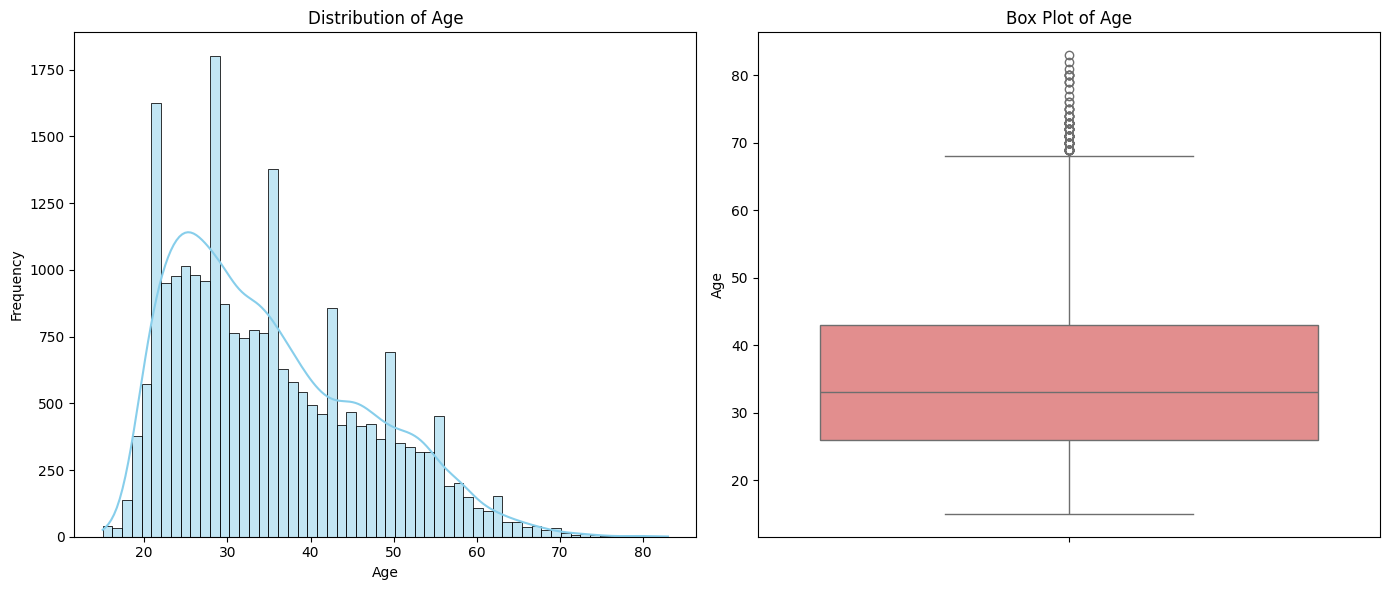

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating histogram and box plot for 'age' column...")

# Create a figure and a set of subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Subplot 2: Box Plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['age'], color='lightcoral')
plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## 3.3 Categorical Data Distributions



Generating bar charts for 'custody_agency', 'sex', and 'race_ethnicity'...


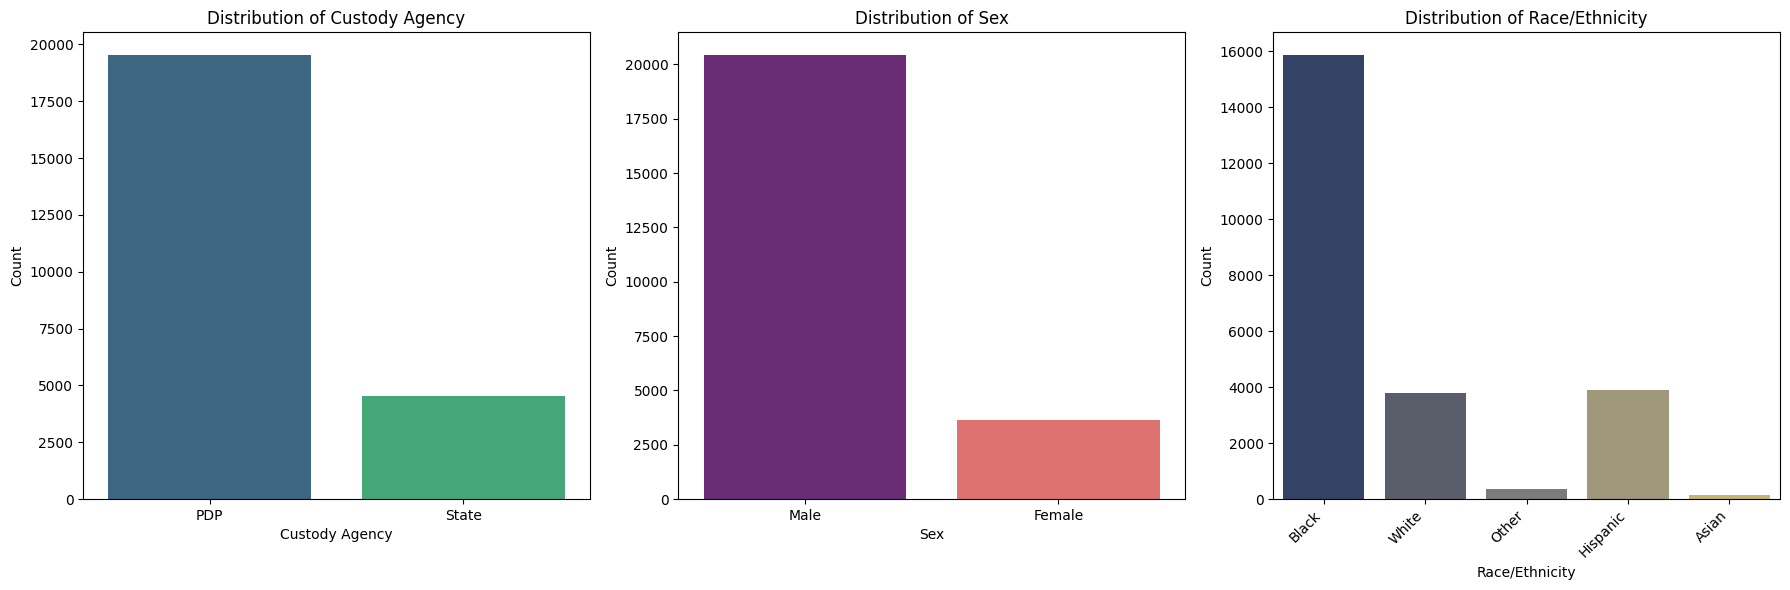

In [ ]:
print("Generating bar charts for 'custody_agency', 'sex', and 'race_ethnicity'...")

plt.figure(figsize=(18, 6)) # Adjust figure size for three subplots

# Subplot 1: custody_agency distribution
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.countplot(x='custody_agency', data=df, palette='viridis', hue='custody_agency', legend=False)
plt.title('Distribution of Custody Agency')
plt.xlabel('Custody Agency')
plt.ylabel('Count')

# Subplot 2: sex distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.countplot(x='sex', data=df, palette='magma', hue='sex', legend=False)
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

# Subplot 3: race_ethnicity distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.countplot(x='race_ethnicity', data=df, palette='cividis', hue='race_ethnicity', legend=False)
plt.title('Distribution of Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

## 3.3 Outlier Detection in Age Using IQR



In [ ]:
print("Identifying outliers in the 'age' column using the IQR method...")

# Calculate Q1 and Q3
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Determine upper and lower bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify and count outliers
outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
outlier_count = len(outliers)

# Print the calculated values and outlier count
print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range (IQR): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")
print(f"Number of identified outliers in 'age' column: {outlier_count}")

Identifying outliers in the 'age' column using the IQR method...
First Quartile (Q1): 26.00
Third Quartile (Q3): 43.00
Interquartile Range (IQR): 17.00
Lower Bound for Outliers: 0.50
Upper Bound for Outliers: 68.50
Number of identified outliers in 'age' column: 91


## 3.5 Descriptive Patterns Related to Disproportionate Incarceration



In [ ]:
print("1. Value counts and proportions for 'custody_agency':")
custody_agency_counts = df['custody_agency'].value_counts()
custody_agency_proportions = df['custody_agency'].value_counts(normalize=True)
print("Counts:\n", custody_agency_counts)
print("Proportions:\n", custody_agency_proportions)

print("\n2. Value counts and proportions for 'sex':")
sex_counts = df['sex'].value_counts()
sex_proportions = df['sex'].value_counts(normalize=True)
print("Counts:\n", sex_counts)
print("Proportions:\n", sex_proportions)

print("\n3. Value counts and proportions for 'race_ethnicity':")
race_ethnicity_counts = df['race_ethnicity'].value_counts()
race_ethnicity_proportions = df['race_ethnicity'].value_counts(normalize=True)
print("Counts:\n", race_ethnicity_counts)
print("Proportions:\n", race_ethnicity_proportions)


1. Value counts and proportions for 'custody_agency':
Counts:
 custody_agency
PDP      19555
State     4534
Name: count, dtype: int64
Proportions:
 custody_agency
PDP      0.811781
State    0.188219
Name: proportion, dtype: float64

2. Value counts and proportions for 'sex':
Counts:
 sex
Male      20451
Female     3638
Name: count, dtype: int64
Proportions:
 sex
Male      0.848977
Female    0.151023
Name: proportion, dtype: float64

3. Value counts and proportions for 'race_ethnicity':
Counts:
 race_ethnicity
Black       15888
Hispanic     3905
White        3775
Other         366
Asian         155
Name: count, dtype: int64
Proportions:
 race_ethnicity
Black       0.659554
Hispanic    0.162107
White       0.156711
Other       0.015194
Asian       0.006434
Name: proportion, dtype: float64


In [ ]:
print("\n4. Value counts and proportions grouped by 'custody_agency' and 'sex':")
custody_sex_counts = df.groupby(['custody_agency', 'sex']).size().unstack(fill_value=0)
custody_sex_proportions = df.groupby(['custody_agency', 'sex']).size().groupby(level=0).apply(lambda x: x / x.sum()).unstack(fill_value=0)
print("Counts:\n", custody_sex_counts)
print("Proportions:\n", custody_sex_proportions)


4. Value counts and proportions grouped by 'custody_agency' and 'sex':
Counts:
 sex             Female   Male
custody_agency               
PDP               3355  16200
State              283   4251
Proportions:
 sex                              Female      Male
custody_agency custody_agency                    
PDP            PDP             0.171567  0.828433
State          State           0.062417  0.937583


In [ ]:
print("5. Value counts and proportions grouped by 'custody_agency' and 'race_ethnicity':")
custody_race_counts = df.groupby(['custody_agency', 'race_ethnicity']).size().unstack(fill_value=0)
custody_race_proportions = df.groupby(['custody_agency', 'race_ethnicity']).size().groupby(level=0).apply(lambda x: x / x.sum()).unstack(fill_value=0)
print("Counts:\n", custody_race_counts)
print("Proportions:\n", custody_race_proportions)

5. Value counts and proportions grouped by 'custody_agency' and 'race_ethnicity':
Counts:
 race_ethnicity  Asian  Black  Hispanic  Other  White
custody_agency                                      
PDP               155  12700      3290    329   3081
State               0   3188       615     37    694
Proportions:
 race_ethnicity                    Asian     Black  Hispanic     Other  \
custody_agency custody_agency                                           
PDP            PDP             0.007926  0.649450  0.168243  0.016824   
State          State           0.000000  0.703132  0.135642  0.008161   

race_ethnicity                    White  
custody_agency custody_agency            
PDP            PDP             0.157556  
State          State           0.153066  


In [ ]:
print("\n6. Value counts and proportions grouped by 'sex' and 'race_ethnicity':")
sex_race_counts = df.groupby(['sex', 'race_ethnicity']).size().unstack(fill_value=0)
sex_race_proportions = df.groupby(['sex', 'race_ethnicity']).size().groupby(level=0).apply(lambda x: x / x.sum()).unstack(fill_value=0)
print("Counts:\n", sex_race_counts)
print("Proportions:\n", sex_race_proportions)


6. Value counts and proportions grouped by 'sex' and 'race_ethnicity':
Counts:
 race_ethnicity  Asian  Black  Hispanic  Other  White
sex                                                 
Female             18   2179       474     56    911
Male              137  13709      3431    310   2864
Proportions:
 race_ethnicity     Asian     Black  Hispanic     Other     White
sex    sex                                                      
Female Female   0.004948  0.598955  0.130291  0.015393  0.250412
Male   Male     0.006699  0.670334  0.167767  0.015158  0.140042


# 4. Statistical Tests

## 4.1 Prepare Data for ANOVA



In [ ]:
print("Extracting 'age' data for each 'race_ethnicity' group...")

# Get unique race_ethnicity groups
unique_races = df['race_ethnicity'].unique()

# Create a list to store age data for each race_ethnicity group
age_data_by_race = []

# Iterate through each unique race_ethnicity group and extract 'age' data
for race in unique_races:
    age_data = df[df['race_ethnicity'] == race]['age'].tolist()
    age_data_by_race.append(age_data)

print("Data extraction complete. Showing the first few elements for each race group (for verification):\n")
for i, race in enumerate(unique_races):
    print(f"'{race}' group (first 5 ages): {age_data_by_race[i][:5]}")
print(f"Total number of race groups: {len(age_data_by_race)}")

Extracting 'age' data for each 'race_ethnicity' group...
Data extraction complete. Showing the first few elements for each race group (for verification):

'Black' group (first 5 ages): [34, 66, 61, 41, 78]
'White' group (first 5 ages): [23, 73, 69, 68, 66]
'Other' group (first 5 ages): [80, 63, 61, 58, 51]
'Hispanic' group (first 5 ages): [70, 65, 65, 65, 64]
'Asian' group (first 5 ages): [55, 53, 45, 51, 47]
Total number of race groups: 5


In [ ]:
print("Calculating and displaying mean age for each 'race_ethnicity' group...")

# Calculate mean age for each race_ethnicity group
mean_ages_by_race = df.groupby('race_ethnicity')['age'].mean()

# Display the mean ages
print("\nMean age for each race_ethnicity group:")
print(mean_ages_by_race)

Calculating and displaying mean age for each 'race_ethnicity' group...

Mean age for each race_ethnicity group:
race_ethnicity
Asian       35.406452
Black       35.176989
Hispanic    33.572343
Other       31.144809
White       36.537483
Name: age, dtype: float64


## 4.2 Visualize the Age distribution

Generating box plot for age distribution by 'race_ethnicity'


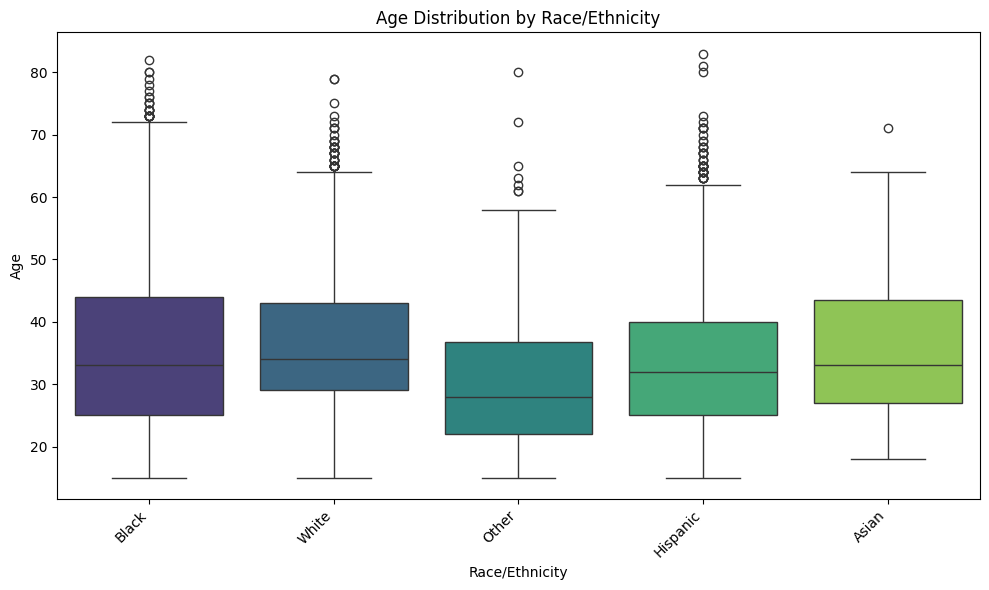

In [ ]:
print("Generating box plot for age distribution by 'race_ethnicity'")

plt.figure(figsize=(10, 6))
sns.boxplot(x='race_ethnicity', y='age', data=df, palette='viridis', hue='race_ethnicity', legend=False)
plt.title('Age Distribution by Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4.3 the One-way ANOVA Test

In [ ]:
from scipy.stats import f_oneway

print("Performing one-way ANOVA test on age across different 'race_ethnicity' groups...")

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(*age_data_by_race)

print(f"\nANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA p-value: {p_value:.3f}")


# Interpret the results (common significance level alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than {alpha}, we reject the null hypothesis.")
    print("There are statistically significant differences in the mean age across different 'race_ethnicity' groups.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than or equal to {alpha}, we fail to reject the null hypothesis.")
    print("There are no statistically significant differences in the mean age across different 'race_ethnicity' groups.")

Performing one-way ANOVA test on age across different 'race_ethnicity' groups...

ANOVA F-statistic: 43.73
ANOVA p-value: 0.000
Since the p-value (0.000) is less than 0.05, we reject the null hypothesis.
There are statistically significant differences in the mean age across different 'race_ethnicity' groups.


# 5. Disproportionate representation

## 5.1 Sample race percentages


In [ ]:
print("Calculating the proportions of each 'race_ethnicity' group...")
release_race_proportions = df['race_ethnicity'].value_counts(normalize=True)
print("Proportions of 'race_ethnicity' groups:")
print(release_race_proportions)

Calculating the proportions of each 'race_ethnicity' group...
Proportions of 'race_ethnicity' groups:
race_ethnicity
Black       0.659554
Hispanic    0.162107
White       0.156711
Other       0.015194
Asian       0.006434
Name: proportion, dtype: float64


## 5.2 City population percentages




In [ ]:
print("Providing approximate racial demographics for Philadelphia...")
# Approximate racial percentages for Philadelphia (Source: US Census Bureau, estimates vary slightly by year)
philadelphia_race_demographics = {
    'Black': 0.40,
    'White': 0.34,
    'Hispanic': 0.15,
    'Asian': 0.08,
    'Other': 0.03 # Combining various smaller groups
}

print("Philadelphia Racial Demographics:")
for race, proportion in philadelphia_race_demographics.items():
    print(f"  {race}: {proportion:.2%}")

Providing approximate racial demographics for Philadelphia...
Philadelphia Racial Demographics:
  Black: 40.00%
  White: 34.00%
  Hispanic: 15.00%
  Asian: 8.00%
  Other: 3.00%


In [ ]:
print("Preparing data for comparison by converting Philadelphia demographics to a Series and aligning with release proportions...")

philadelphia_series = pd.Series(philadelphia_race_demographics, name='Philadelphia_Proportion')

# Ensure both Series have the same index for direct comparison
# Reindex philadelphia_series to match the index of release_race_proportions
philadelphia_series = philadelphia_series.reindex(release_race_proportions.index, fill_value=0)

# Combine into a single DataFrame for easier comparison
comparison_df = pd.DataFrame({
    'Release_Proportion': release_race_proportions,
    'Philadelphia_Proportion': philadelphia_series
})

print("Comparison DataFrame created:")
display(comparison_df)

Preparing data for comparison by converting Philadelphia demographics to a Series and aligning with release proportions...
Comparison DataFrame created:


,Release_Proportion,Philadelphia_Proportion
race_ethnicity,,
Black,0.659554,0.40
Hispanic,0.162107,0.15
White,0.156711,0.34
Other,0.015194,0.03
Asian,0.006434,0.08


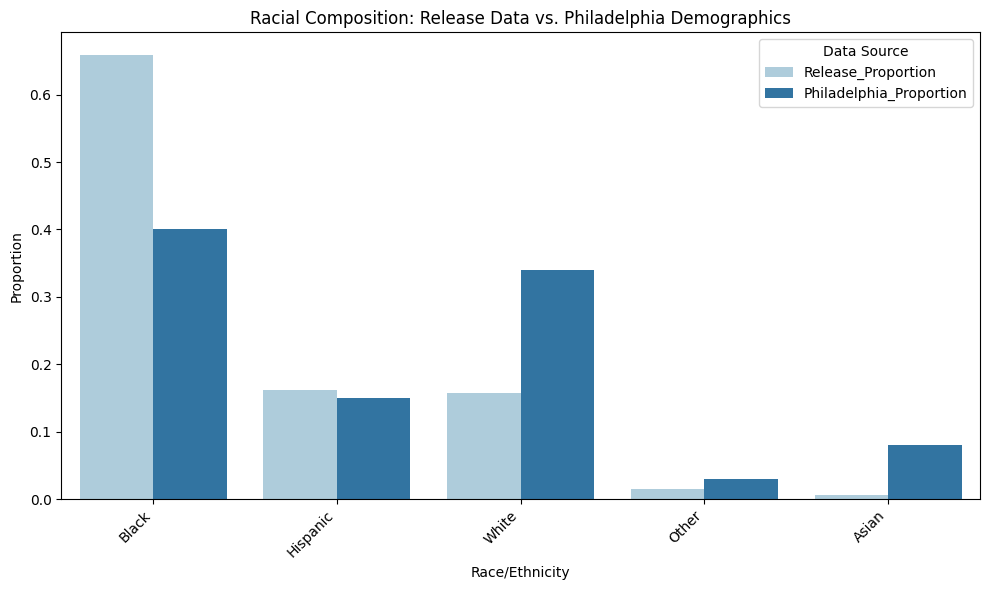

In [ ]:
comparison_df_plot = comparison_df.reset_index().melt(id_vars='race_ethnicity', var_name='Data_Source', value_name='Proportion')

plt.figure(figsize=(10, 6))
sns.barplot(x='race_ethnicity', y='Proportion', hue='Data_Source', data=comparison_df_plot, palette='Paired')

plt.title('Racial Composition: Release Data vs. Philadelphia Demographics')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

## 5.3 Comparison Table


In [ ]:
print("Calculating 'Overrepresentation_Ratio' and renaming columns...")

# Calculate 'Overrepresentation_Ratio'
comparison_df['Overrepresentation_Ratio'] = comparison_df['Release_Proportion'] / comparison_df['Philadelphia_Proportion']

# Rename columns
comparison_df.rename(columns={
    'Release_Proportion': 'Sample_%',
    'Philadelphia_Proportion': 'City_%'
}, inplace=True)

# Display the updated DataFrame
print("Updated Comparison Table:")
display(comparison_df)

Calculating 'Overrepresentation_Ratio' and renaming columns...
Updated Comparison Table:


,Sample_%,City_%,Overrepresentation_Ratio
race_ethnicity,,,
Black,0.659554,0.40,1.648885
Hispanic,0.162107,0.15,1.080715
White,0.156711,0.34,0.460913
Other,0.015194,0.03,0.506455
Asian,0.006434,0.08,0.080431


# 6. Intersectional Disparities by Race and Sex


## 6.1 Release Proportions by Race and Sex



In [ ]:
print("Calculating proportions of releases for each unique combination of 'race_ethnicity' and 'sex'...")

# Group by 'race_ethnicity' and 'sex' and calculate the size of each group
release_race_sex_counts = df.groupby(['race_ethnicity', 'sex']).size()

# Calculate the proportions by dividing by the total number of rows in the DataFrame
release_race_sex_proportions = release_race_sex_counts / len(df)

print("Proportions of releases by 'race_ethnicity' and 'sex':")
print(release_race_sex_proportions)

Calculating proportions of releases for each unique combination of 'race_ethnicity' and 'sex'...
Proportions of releases by 'race_ethnicity' and 'sex':
race_ethnicity  sex   
Asian           Female    0.000747
                Male      0.005687
Black           Female    0.090456
                Male      0.569098
Hispanic        Female    0.019677
                Male      0.142430
Other           Female    0.002325
                Male      0.012869
White           Female    0.037818
                Male      0.118892
dtype: float64


## 6.2 Estimated City Proportions by Race × Sex



In [ ]:
print("Calculating estimated city-level demographic proportions by race and sex...")

# Define the estimated sex ratio for Philadelphia
# Source: US Census Bureau (approximate values)
philadelphia_sex_ratio = {
    'Male': 0.48,
    'Female': 0.52
}

# Create a dictionary to store the estimated city-level race-sex proportions
philadelphia_race_sex_demographics = {}

# Iterate through the existing philadelphia_race_demographics
for race, race_prop in philadelphia_race_demographics.items():
    for sex, sex_prop in philadelphia_sex_ratio.items():
        # Calculate the proportion for the specific race-sex combination
        philadelphia_race_sex_demographics[(race, sex)] = race_prop * sex_prop

# Convert the dictionary to a pandas Series for easier handling
philadelphia_race_sex_proportions = pd.Series(philadelphia_race_sex_demographics, name='Philadelphia_Race_Sex_Proportion')

print("Estimated Philadelphia Race-Sex Demographics:")
print(philadelphia_race_sex_proportions)

Calculating estimated city-level demographic proportions by race and sex...
Estimated Philadelphia Race-Sex Demographics:
Black     Male      0.1920
          Female    0.2080
White     Male      0.1632
          Female    0.1768
Hispanic  Male      0.0720
          Female    0.0780
Asian     Male      0.0384
          Female    0.0416
Other     Male      0.0144
          Female    0.0156
Name: Philadelphia_Race_Sex_Proportion, dtype: float64


## 6.3 Build Intersectional Comparison Table



In [ ]:
print("Creating intersectional comparison table and calculating 'Overrepresentation_Ratio'...")

# Ensure both Series have the same multi-index and are aligned
# Reindex philadelphia_race_sex_proportions to match the index of release_race_sex_proportions
philadelphia_race_sex_proportions_aligned = philadelphia_race_sex_proportions.reindex(release_race_sex_proportions.index, fill_value=0)

# Combine into a single DataFrame
intersectional_comparison_df = pd.DataFrame({
    'Sample_%': release_race_sex_proportions,
    'City_%': philadelphia_race_sex_proportions_aligned
})

# Calculate 'Overrepresentation_Ratio'
intersectional_comparison_df['Overrepresentation_Ratio'] = intersectional_comparison_df['Sample_%'] / intersectional_comparison_df['City_%']

print("Intersectional Comparison Table:")
display(intersectional_comparison_df)

Creating intersectional comparison table and calculating 'Overrepresentation_Ratio'...
Intersectional Comparison Table:


Sample_%  City_%  Overrepresentation_Ratio
race_ethnicity sex                                               
Asian          Female  0.000747  0.0416                  0.017962
               Male    0.005687  0.0384                  0.148105
Black          Female  0.090456  0.2080                  0.434886
               Male    0.569098  0.1920                  2.964052
Hispanic       Female  0.019677  0.0780                  0.252270
               Male    0.142430  0.0720                  1.978197
Other          Female  0.002325  0.0156                  0.149020
               Male    0.012869  0.0144                  0.893677
White          Female  0.037818  0.1768                  0.213903
               Male    0.118892  0.1632                  0.728508

## 6.4 Visualize Intersectional Disparities


Generating grouped bar chart for intersectional disparities...


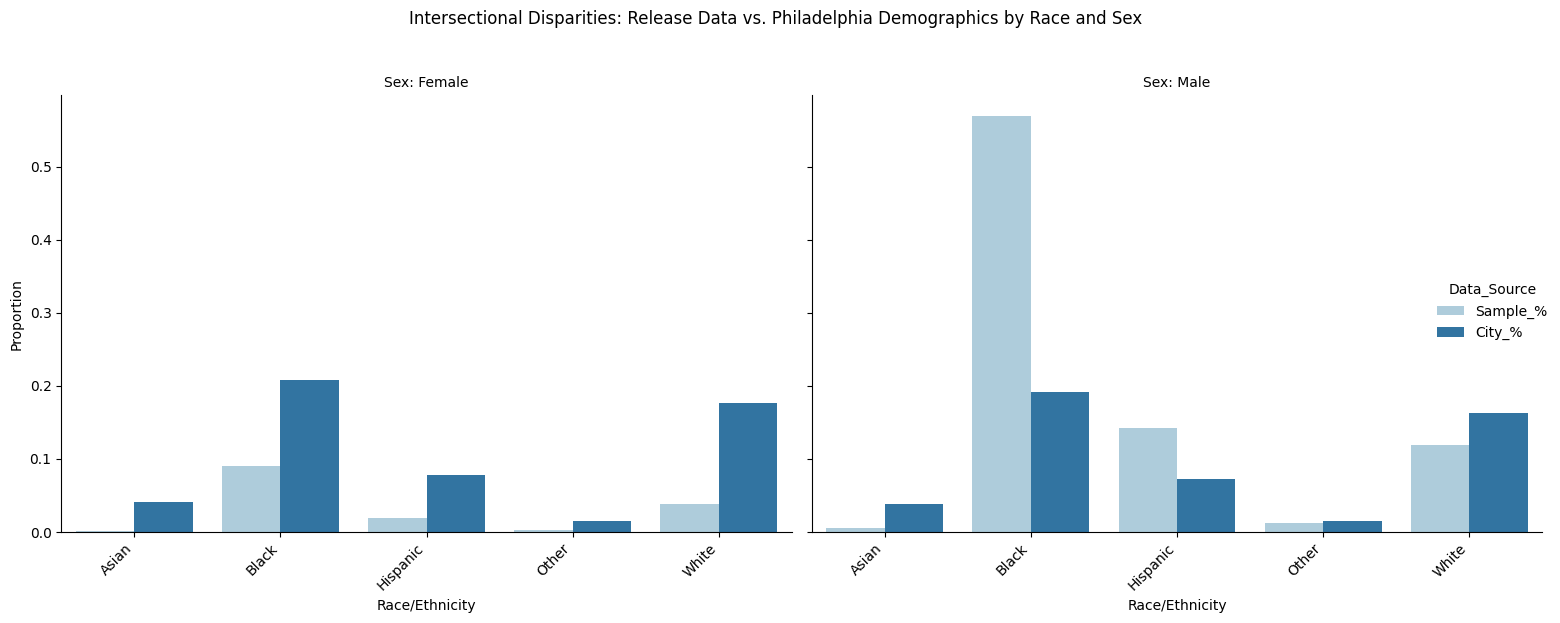

In [ ]:
print("Generating grouped bar chart for intersectional disparities...")

# Reset index to make 'race_ethnicity' and 'sex' columns
intersectional_comparison_df_plot = intersectional_comparison_df.reset_index()

# Melt the DataFrame to long format for easier plotting with seaborn
intersectional_comparison_df_plot = intersectional_comparison_df_plot.melt(
    id_vars=['race_ethnicity', 'sex'],
    value_vars=['Sample_%', 'City_%'],
    var_name='Data_Source',
    value_name='Proportion'
)

# Use catplot for faceting by 'sex'
g = sns.catplot(
    x='race_ethnicity',
    y='Proportion',
    hue='Data_Source',
    col='sex', # Use 'sex' for column faceting to separate male and female
    data=intersectional_comparison_df_plot,
    kind='bar',
    palette='Paired',
    height=6, aspect=1.2 # Adjust height and aspect for better readability
)

# Set titles and labels for each subplot
g.set_axis_labels("Race/Ethnicity", "Proportion")
g.set_xticklabels(rotation=45, ha='right')
g.set_titles("Sex: {col_name}")
g.fig.suptitle('Intersectional Disparities: Release Data vs. Philadelphia Demographics by Race and Sex', y=1.03) # Adjust title position

plt.tight_layout()
plt.show()